In [2]:
%load_ext autoreload
%autoreload 2
import sys
if ".." not in sys.path:
    sys.path.append("..")

from types import SimpleNamespace

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

from signature.learning.signature_transform import RollingSignatureTransform, EFMSignatureTransform
from signature.learning.hyperparameters_optimization import optimize_lam_cv, grid_search_cv, grid_search_efm
import signature.tensor_algebra as ta

my_green = "#5b6c64"
my_copper = "#B56246"
plt.rcParams["figure.figsize"]        = ((1 + np.sqrt(5)) / 2 * 5, 5)
plt.rcParams["figure.autolayout"]     = True
plt.rcParams["patch.force_edgecolor"] = False
plt.rcParams["axes.grid"]             = True
plt.rcParams['axes.prop_cycle']       = matplotlib.cycler(color=[my_green, my_copper, "#322B4D", "#28BC9C", "#71074E"])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## BTC data


In [3]:
df = pd.read_csv("data/CLOSE_RV_VIX.csv", index_col="date")
df.index = pd.to_datetime(df.index)
df


,BTC-PERPETUAL_rv_5m,BTC-PERPETUAL_close_2h,BTC_USDC_rv_5m,BTC_USDC_close_2h,BTC_USDT_rv_5m,BTC_USDT_close_2h,BTC-PERPETUAL_rvol_5m,BTC_USDC_rvol_5m,BTC_USDT_rvol_5m,vs_raw_30d,svs_raw_30d,vix_30d,svix_30d
date,,,,,,,,,,,,,
2019-01-01,0.000735,3683.5,NaN,NaN,NaN,NaN,0.517952,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-02,0.000447,3794.0,NaN,NaN,NaN,NaN,0.404055,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-03,0.000389,3863.0,NaN,NaN,NaN,NaN,0.376857,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-04,0.000413,3780.0,NaN,NaN,NaN,NaN,0.388192,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-05,0.000467,3839.0,NaN,NaN,NaN,NaN,0.412726,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-11,0.000313,81543.0,0.000326,81526.0,0.000355,81536.0,0.338262,0.344806,0.359921,0.014100,0.013054,0.414188,0.398532
2026-05-12,0.000226,81269.0,0.000262,81251.0,0.000240,81277.0,0.287220,0.309183,0.295803,0.013870,0.013002,0.410793,0.397726
2026-05-13,0.000195,80968.5,0.000231,80954.0,0.000227,80965.0,0.266943,0.290428,0.288156,0.013806,0.012681,0.409848,0.392793


## Column availability

Each column comes from a different venue / estimator and is available over a different date
range (e.g. `BTC_USDT_*` only starts in late 2023, the `*_30d` vol indices only start in
late 2024). `describe_column_coverage` reports the first date, last date and observation count
for every column so that, after picking the columns below, train/test dates can be chosen with
the actual available range in mind instead of guessing.


In [4]:
def describe_column_coverage(df):
    """First/last non-null date and observation count for every column of `df`."""
    rows = []
    for col in df.columns:
        s = df[col].dropna()
        rows.append({
            "column": col,
            "first_date": s.index.min() if len(s) else None,
            "last_date": s.index.max() if len(s) else None,
            "n_obs": len(s),
        })
    return pd.DataFrame(rows).set_index("column")

describe_column_coverage(df)


,first_date,last_date,n_obs
column,,,
BTC-PERPETUAL_rv_5m,2019-01-01,2026-05-15,2692
BTC-PERPETUAL_close_2h,2019-01-01,2026-05-15,2692
BTC_USDC_rv_5m,2023-04-24,2026-05-15,1118
BTC_USDC_close_2h,2023-04-25,2026-05-15,1117
BTC_USDT_rv_5m,2023-12-12,2026-05-15,886
BTC_USDT_close_2h,2023-12-13,2026-05-15,885
BTC-PERPETUAL_rvol_5m,2019-01-01,2026-05-15,2692
BTC_USDC_rvol_5m,2023-04-24,2026-05-15,1118
BTC_USDT_rvol_5m,2023-12-12,2026-05-15,886


## Column selection

- `underlying_col`: price series used to build the log-price path feature.
- `qv_col`: realized-variance column (e.g. a 5-minute realized variance) cumulated into the
  quadratic-variation path feature. Set to `None` to instead use the sum of squared daily
  log-return increments of `underlying_col`, as in the SPX/VIX reference notebook.
- `target_col`: the column the model tries to predict (a BTC implied/synthetic vol index).


In [8]:
underlying_col = "BTC-PERPETUAL_close_2h"
qv_col = "BTC-PERPETUAL_rv_5m"  # set to None to use the sum of squared log-return increments instead
target_col = "vix_30d"

required_cols = [underlying_col] + ([qv_col] if qv_col else [])
usable_index = df.dropna(subset=required_cols).index
print(f"Usable range for underlying_col={underlying_col!r}, qv_col={qv_col!r}: "
      f"{usable_index.min().date()} -> {usable_index.max().date()} ({len(usable_index)} obs)")

target_coverage = df[target_col].dropna()
print(f"Target column target_col={target_col!r} available: "
      f"{target_coverage.index.min().date()} -> {target_coverage.index.max().date()} ({len(target_coverage)} obs)")


Usable range for underlying_col='BTC-PERPETUAL_close_2h', qv_col='BTC-PERPETUAL_rv_5m': 2019-01-01 -> 2026-05-15 (2692 obs)
Target column target_col='vix_30d' available: 2024-11-18 -> 2026-05-15 (544 obs)


## Train / test dates

Pick `train_start_date` (the burn-in cutoff) and `test_start_date`/`test_end_date` using the
usable ranges printed above: `train_start_date` should be at or after the "usable range" start
(so the underlying and QV path features are defined throughout burn-in and training), and
`test_start_date` should fall within the target column's available range.


In [17]:
train_start_date = pd.to_datetime('2019-06-01')
test_start_date = pd.to_datetime('2026-01-01')
test_end_date = pd.to_datetime('2026-05-15')


## Helper functions

Mirrors the per-index helpers from the multi-index SPX/VIX notebook: `load_btc_series` selects
the chosen columns, restricts to the date range where the underlying (and QV column, if used)
are both defined, and computes the relative time grid / train-test threshold / burn-in row
count. `finalize_dataset` then applies the EFM-signature transform and splits train/test on
that threshold, masking out rows where the target is NaN (since `target_col` can start later
than `underlying_col`/`qv_col`).


In [18]:
def load_btc_series(df, underlying_col, target_col, qv_col, train_start_date, test_start_date, test_end_date):
    """Select underlying/target/qv columns and the bookkeeping needed to build EFM-signature
    features: a relative time grid, the train/test threshold expressed on that same grid, and
    the burn-in row count.

    Rows are restricted to `index <= test_end_date` and to dates where `underlying_col` (and
    `qv_col`, if used) are non-null, so that the path features used by the signature transform
    are always defined; `target_col` may still contain NaNs, handled later by `finalize_dataset`.
    """
    required_cols = [underlying_col] + ([qv_col] if qv_col else [])
    cols = sorted(set(required_cols + [target_col]))
    sub = df.loc[df.index <= test_end_date, cols].dropna(subset=required_cols)

    index = sub.index
    time_grid = np.array((index - index[0]).days / 365)
    test_threshold = (test_start_date - index[0]).days / 365
    dates_grid = pd.to_datetime(pd.Series(index))
    burn_in = np.where(index >= train_start_date)[0][0]
    return SimpleNamespace(
        underlying=sub[underlying_col],
        target=sub[target_col],
        qv=sub[qv_col] if qv_col else None,
        time_grid=time_grid,
        dates_grid=dates_grid,
        test_threshold=test_threshold,
        burn_in=burn_in,
    )


def build_quadratic_variation(asset):
    """Cumulative quadratic-variation path feature.

    Uses the chosen realized-variance column (`asset.qv`) when available; otherwise falls back
    to the sum of squared daily log-return increments of the underlying, as in the SPX/VIX
    reference notebook.
    """
    if asset.qv is not None:
        return np.cumsum(np.asarray(asset.qv))
    log_price = np.log(np.asarray(asset.underlying))
    return np.concatenate([[0], np.cumsum(np.diff(log_price) ** 2)])


def finalize_dataset(X_raw, y_full, asset, trunc, lam, **efm_kwargs):
    """Apply the EFM-signature transform and split train/test on `asset.test_threshold`.

    The transform is causal -- the signature at row t only depends on the path up to and
    including row t -- so transforming the full series before splitting introduces no leakage.
    The split compares each row's date against the same calendar `test_start_date` used to
    build `asset.test_threshold`, so every training date is strictly before every test date
    (checked by the assertion below).
    """
    burn_in = asset.burn_in
    y = np.array(y_full[burn_in:])

    transformer = EFMSignatureTransform(trunc=trunc, lam=lam, burn_in=burn_in, **efm_kwargs)
    X = transformer.fit_transform(X_raw, y)

    mask = ~np.isnan(y)
    X, y = X[mask], y[mask]
    time_grid_masked = asset.time_grid[burn_in:][mask]
    dates_masked = asset.dates_grid[burn_in:][mask]

    is_train = time_grid_masked < asset.test_threshold
    data = SimpleNamespace(
        X=X, y=y,
        X_train=X[is_train], y_train=y[is_train],
        X_test=X[~is_train], y_test=y[~is_train],
        dates=dates_masked, dates_train=dates_masked[is_train], dates_test=dates_masked[~is_train],
        time_grid=time_grid_masked,
    )
    if data.dates_train.size and data.dates_test.size:
        assert data.dates_train.max() < data.dates_test.min(), "training dates overlap with test dates"
    return data


def regression_metrics(y_true, y_pred):
    return {"RMSE": np.sqrt(mean_squared_error(y_true, y_pred)), "R2": r2_score(y_true, y_pred)}


def print_train_test_metrics(y_train, y_pred_train, y_test, y_pred_test, label=None):
    if label:
        print(f"{label} metrics:")
    for split, (y_true, y_pred) in {"Train": (y_train, y_pred_train), "Test": (y_test, y_pred_test)}.items():
        m = regression_metrics(y_true, y_pred)
        print(f"  {split}: RMSE = {m['RMSE']:.4f}, R2 = {m['R2']:.4f}")


def plot_fit(dates, y, y_pred, test_start_date, title=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(dates, y, label=target_col)
    ax.plot(dates, y_pred, "--", label="Predicted")
    ax.vlines(x=test_start_date, ymin=0.95 * np.min(y), ymax=1.05 * np.max(y), color="k")
    ax.legend(loc="upper left")
    if title:
        ax.set_title(title)
    plt.show()
    return fig


In [19]:
asset = load_btc_series(df, underlying_col, target_col, qv_col, train_start_date, test_start_date, test_end_date)
underlying = asset.underlying
target = asset.target
time_grid = asset.time_grid
dates_grid = asset.dates_grid
burn_in = asset.burn_in

print("Burn-in:", burn_in)
print(f"Working range: {dates_grid.min().date()} -> {dates_grid.max().date()} ({len(dates_grid)} obs)")


Burn-in: 151
Working range: 2019-01-01 -> 2026-05-15 (2692 obs)


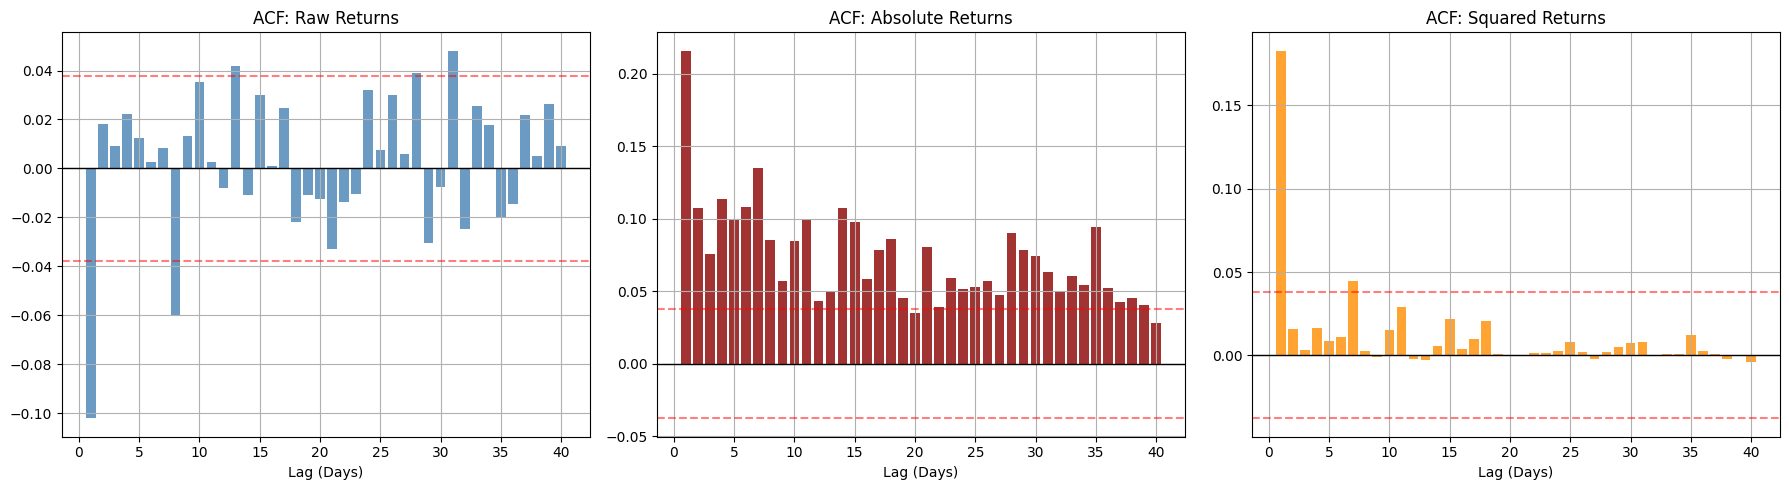

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

# Assuming 'underlying' is your array of daily prices: returns = np.diff(np.log(underlying))
returns = np.diff(np.log(underlying))

lags = 40
acf_raw = acf(returns, nlags=lags, fft=True)
acf_abs = acf(np.abs(returns), nlags=lags, fft=True)
acf_sq  = acf(returns**2, nlags=lags, fft=True)

# Plotting the three perspectives
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
lags_idx = np.arange(lags + 1)
conf_interval = 1.96 / np.sqrt(len(returns)) # 95% Confidence Band

titles = ['ACF: Raw Returns', 'ACF: Absolute Returns', 'ACF: Squared Returns']
data_list = [acf_raw, acf_abs, acf_sq]
colors = ['steelblue', 'darkred', 'darkorange']

for i in range(3):
    axes[i].bar(lags_idx[1:], data_list[i][1:], color=colors[i], alpha=0.8)
    axes[i].axhline(y=0, color='black', lw=1)
    axes[i].axhline(y=conf_interval, color='red', linestyle='--', alpha=0.5)
    axes[i].axhline(y=-conf_interval, color='red', linestyle='--', alpha=0.5)
    axes[i].set_title(titles[i])
    axes[i].set_xlabel('Lag (Days)')

plt.tight_layout()
plt.show()


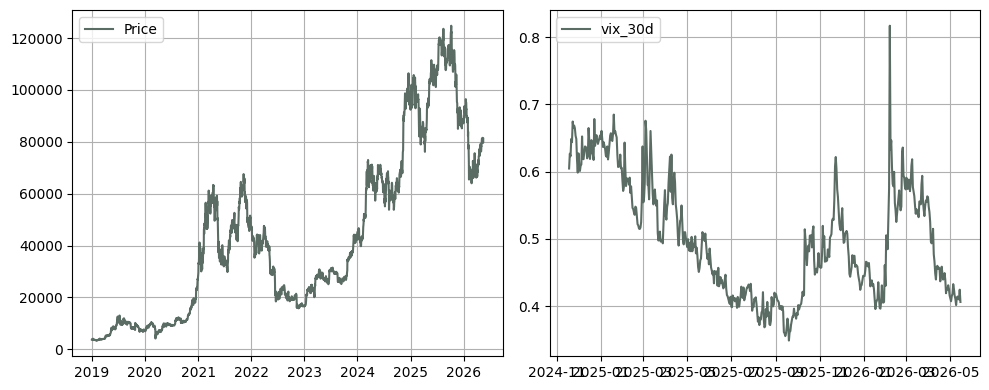

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(dates_grid, underlying, label="Price")
ax[0].legend()
ax[1].plot(dates_grid, target, label=target_col)
ax[1].legend()


## EFM-Signature model


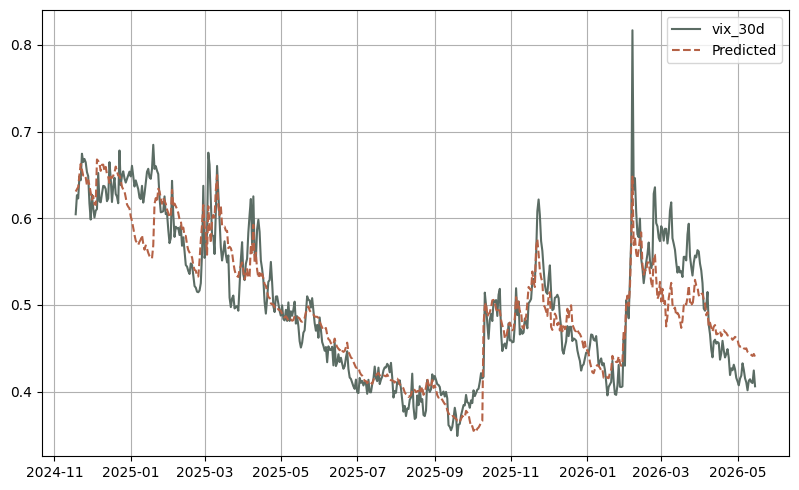

In [22]:
log_price = np.log(underlying)
quadratic_variation = build_quadratic_variation(asset)

path = np.vstack([
    time_grid,
    log_price / 10,
    quadratic_variation,
]).T
trunc = 2
lam = np.array([10, 10, 10])
kwargs = {}

dim = path.shape[1]
if "lead_lag_idx" in kwargs:
    dim += kwargs["lead_lag_idx"].size

X_raw = np.hstack([time_grid[:, None], path])
data = finalize_dataset(X_raw, np.array(target), asset, trunc, lam, **kwargs)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Ridge())
])

# Fit on the training window only: fitting on the full series and only later reporting
# test-period metrics would leak future information into the model and make the test
# metrics meaningless.
pipe.fit(data.X_train, data.y_train)

plt.plot(data.dates, data.y, label=target_col)
plt.plot(data.dates, pipe.predict(data.X), "--", label="Predicted")
plt.legend()


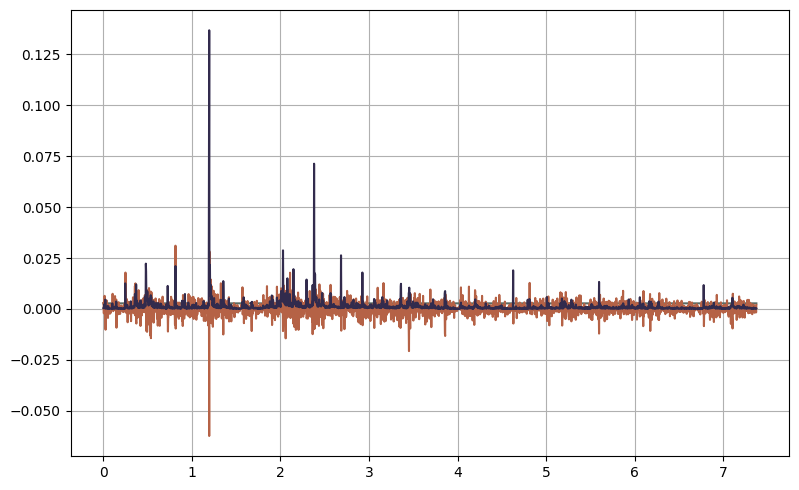

In [23]:
plt.plot(time_grid[1:], np.diff(path[:, 0], axis=0))
plt.plot(time_grid[1:], np.diff(path[:, 1], axis=0))
plt.plot(time_grid[1:], np.diff(path[:, 2], axis=0))


  Train: RMSE = 0.0280, R2 = 0.9012
  Test: RMSE = 0.0440, R2 = 0.6625


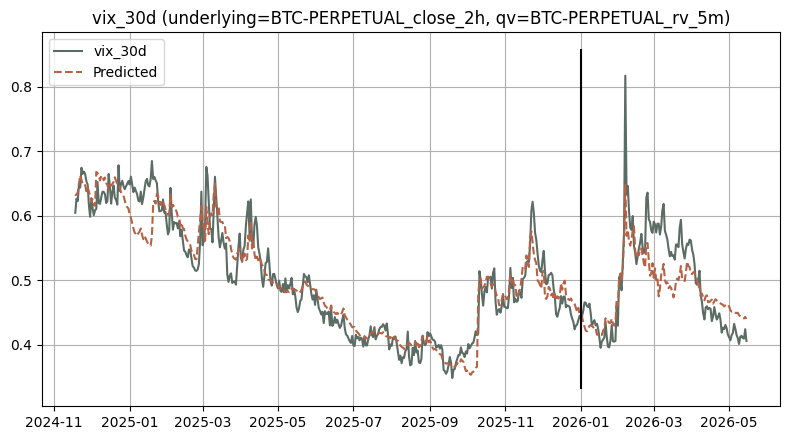

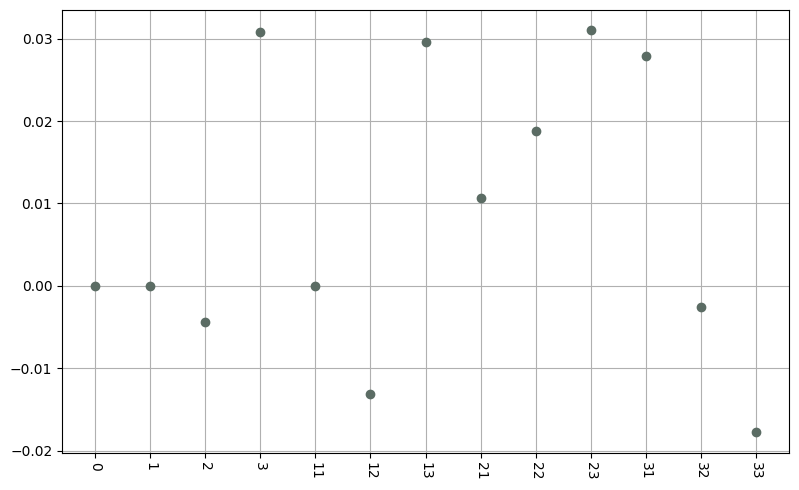

In [24]:
y_pred_train = pipe.predict(data.X_train)
y_pred_test = pipe.predict(data.X_test)
print_train_test_metrics(data.y_train, y_pred_train, data.y_test, y_pred_test)

fig = plot_fit(data.dates, data.y, pipe.predict(data.X), test_start_date,
               title=f"{target_col} (underlying={underlying_col}, qv={qv_col})")
# fig.savefig("BTC-Vol-EFM-Signature.pdf", format="pdf", transparent=True, bbox_inches="tight")

vol_coef = ta.from_array(array=pipe["regressor"].coef_, dim=dim, trunc=trunc)
ta.plot_coefficients(vol_coef, trunc=trunc)


### Optimize the hyper-parameters


In [13]:
# NOTE: tuning `lam` this way requires refitting the EFM-signature transform on each CV fold,
# which means `EFMSignatureTransform` must be a step inside `pipe` (e.g. named 'sig') so that
# `pipe.set_params(sig__lam=...)` and `clone(pipe).fit(...)` recompute the signature with the
# candidate lam. The pipeline above only has 'scaler' and 'regressor' steps -- `lam` is applied
# once, upfront, when building `data` via finalize_dataset() -- so this cell is left disabled
# rather than wired in. Wiring it back in would also mean passing raw (untransformed) path data
# and revisiting the NaN-handling for target gaps, since `tscv_loop` indexes into the raw,
# pre-mask arrays by row count, which the current drop-NaN-rows-after-transform approach is
# incompatible with.

# lam_dim = lam.size
# lam_opt = optimize_lam_cv(X=data.X_train, y=data.y_train, model=pipe, burn_in=burn_in,
#                           bounds=[(1, 20)] * lam_dim, init_guess=[5] * lam_dim,
#                           optimizer="Powell")
# pipe.set_params(sig__lam=lam_opt)


### Grid Search optimization


In [14]:
# See the note in the cell above: this grid search also relies on `pipe` containing a 'sig'
# step, which it currently does not, so it is left disabled too.

# import itertools
#
# lambda_axis = np.array([1, 2, 3, 5, 7, 10, 15, 20, 30])
# lambda_3d_grid = [np.array(p) for p in itertools.product(lambda_axis, repeat=3)]
#
# param_grid = {
#     'sig__lam': lambda_3d_grid,
#     'regressor__alpha': [0.1, 1.0, 10.0]
# }
#
# best_p, all_results = grid_search_efm(
#     X=data.X_train,
#     y=data.y_train,
#     model=pipe,
#     param_grid=param_grid,
#     burn_in=burn_in
# )
#
# print("\nBest Parameters Found:")
# print(best_p)
